# 04_modeling_clustering.ipynb
Segmentación de propiedades con KMeans y visualización interactiva.

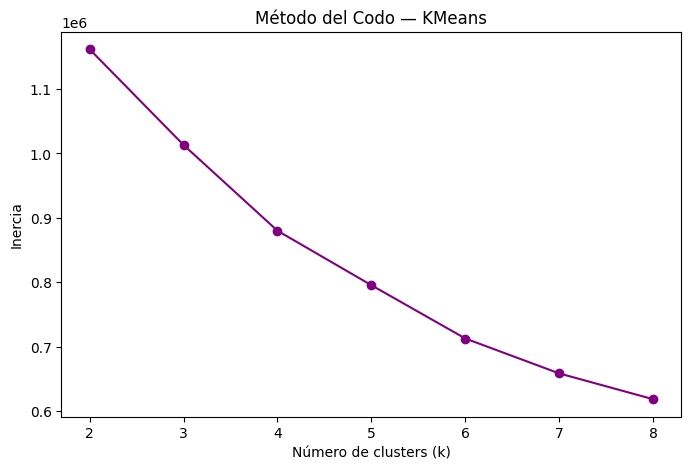

In [1]:
import warnings
warnings.filterwarnings('ignore')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_csv('../data/processed/house_prices_clean.csv')
cluster_features = [
    'bhk_count', 'carpet_area_num', 'price_per_sqft',
    'furnishing_score', 'has_parking', 'is_luxury',
    'Bathroom', 'floor_ratio', 'city_avg_price'
]
df_cluster = df[cluster_features].dropna().copy()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)
joblib.dump(scaler, '../app/scaler_kmeans.pkl')

inertias = []
k_range = range(2, 9)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(list(k_range), inertias, marker='o', color='purple')
plt.xlabel('Número de clusters (k)')
plt.ylabel('Inercia')
plt.title('Método del Codo — KMeans')
plt.savefig('../reports/figures/09_elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

In [2]:
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
df_cluster['cluster'] = kmeans.fit_predict(X_scaled)
joblib.dump(kmeans, '../app/model_kmeans.pkl')

display(df_cluster.groupby('cluster').median().round(2))

,bhk_count,carpet_area_num,price_per_sqft,furnishing_score,has_parking,is_luxury,Bathroom,floor_ratio,city_avg_price
cluster,,,,,,,,,
0,3.0,1300.0,8086.64,1.0,1.0,0.0,3.0,0.5,6900000.0
1,2.0,800.0,6500.00,1.0,0.0,0.0,2.0,0.5,6500000.0
2,2.0,688.0,5813.95,0.0,402.0,0.0,2.0,1.0,6900000.0
3,2.0,105.0,53488.37,0.0,0.0,1.0,2.0,0.5,7100000.0


## Asignación de nombres a clusters
Puedes ajustar los nombres según las medianas que observes en la tabla anterior.

In [4]:
cluster_labels = {
    0: 'Inversión Económica',
    1: 'Perfil Familiar',
    2: 'Perfil Ejecutivo',
    3: 'Lujo Premium'
}

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df_cluster['PCA1'] = X_pca[:, 0]
df_cluster['PCA2'] = X_pca[:, 1]
df_cluster['perfil'] = df_cluster['cluster'].map(cluster_labels)

fig = px.scatter(
    df_cluster.sample(min(5000, len(df_cluster)), random_state=42),
    x='PCA1', y='PCA2', color='perfil',
    hover_data=['bhk_count', 'carpet_area_num', 'price_per_sqft', 'furnishing_score'],
    title='Segmentación de Propiedades por Perfil de Estilo de Vida (PCA)'
 )
fig.write_html('../reports/figures/10_clusters_interactivo.html')
try:
    import plotly.io as pio
    pio.renderers.default = 'browser'
    fig.show()
except Exception as e:
    print('No se pudo mostrar la gráfica en el notebook:', e)
    print('El archivo interactivo se guardó en reports/figures/10_clusters_interactivo.html')